# Chapter 13: Synthetic Data Generation

**AFML Ch. 13** -- Ornstein-Uhlenbeck process for synthetic data.

Synthetic data lets us test strategies in controlled conditions where
we know the true data-generating process. The Ornstein-Uhlenbeck (OU)
process is particularly useful because it exhibits mean-reversion, a
property found in many financial time series.

This notebook demonstrates:

- Simulating OU processes with different parameters
- Estimating OU parameters from observed data
- Parameter recovery accuracy across multiple seeds
- Effect of sample size on estimation quality

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymlfinance

%matplotlib inline
np.random.seed(42)

## Ornstein-Uhlenbeck Process

The OU process is defined by the stochastic differential equation:

$$dX = \theta (\mu - X)\, dt + \sigma\, dW$$

where:
- $\theta$ controls the speed of mean reversion
- $\mu$ is the long-run mean
- $\sigma$ is the volatility

We simulate paths with four different parameter sets to illustrate
how each parameter affects the trajectory.

In [2]:
params = [
    {"theta": 1.0, "mu": 0.0, "sigma": 0.5, "label": "Fast mean-reversion"},
    {"theta": 0.1, "mu": 0.0, "sigma": 0.5, "label": "Slow mean-reversion"},
    {"theta": 1.0, "mu": 5.0, "sigma": 0.5, "label": "Non-zero mean"},
    {"theta": 1.0, "mu": 0.0, "sigma": 2.0, "label": "High volatility"},
]

for p in params:
    path = pymlfinance.backtesting.simulate_ou(
        theta=p["theta"], mu=p["mu"], sigma=p["sigma"],
        x0=p["mu"], dt=0.01, n_steps=1000, seed=42
    )
    print(f"{p['label']:30s} theta={p['theta']}, mu={p['mu']}, sigma={p['sigma']}")
    print(f"  Path: mean={np.mean(path):.4f}, std={np.std(path):.4f}, "
          f"min={np.min(path):.4f}, max={np.max(path):.4f}")

Fast mean-reversion            theta=1.0, mu=0.0, sigma=0.5
  Path: mean=0.0417, std=0.2142, min=-0.5031, max=0.5031
Slow mean-reversion            theta=0.1, mu=0.0, sigma=0.5
  Path: mean=0.0572, std=0.3231, min=-0.6928, max=0.7814
Non-zero mean                  theta=1.0, mu=5.0, sigma=0.5
  Path: mean=5.0417, std=0.2142, min=4.4969, max=5.5031
High volatility                theta=1.0, mu=0.0, sigma=2.0
  Path: mean=0.1669, std=0.8569, min=-2.0122, max=2.0125


### Visualisation: OU Sample Paths

The four parameter sets produce visually distinct paths. Fast mean
reversion stays close to the long-run mean, while slow reversion
allows wider excursions.

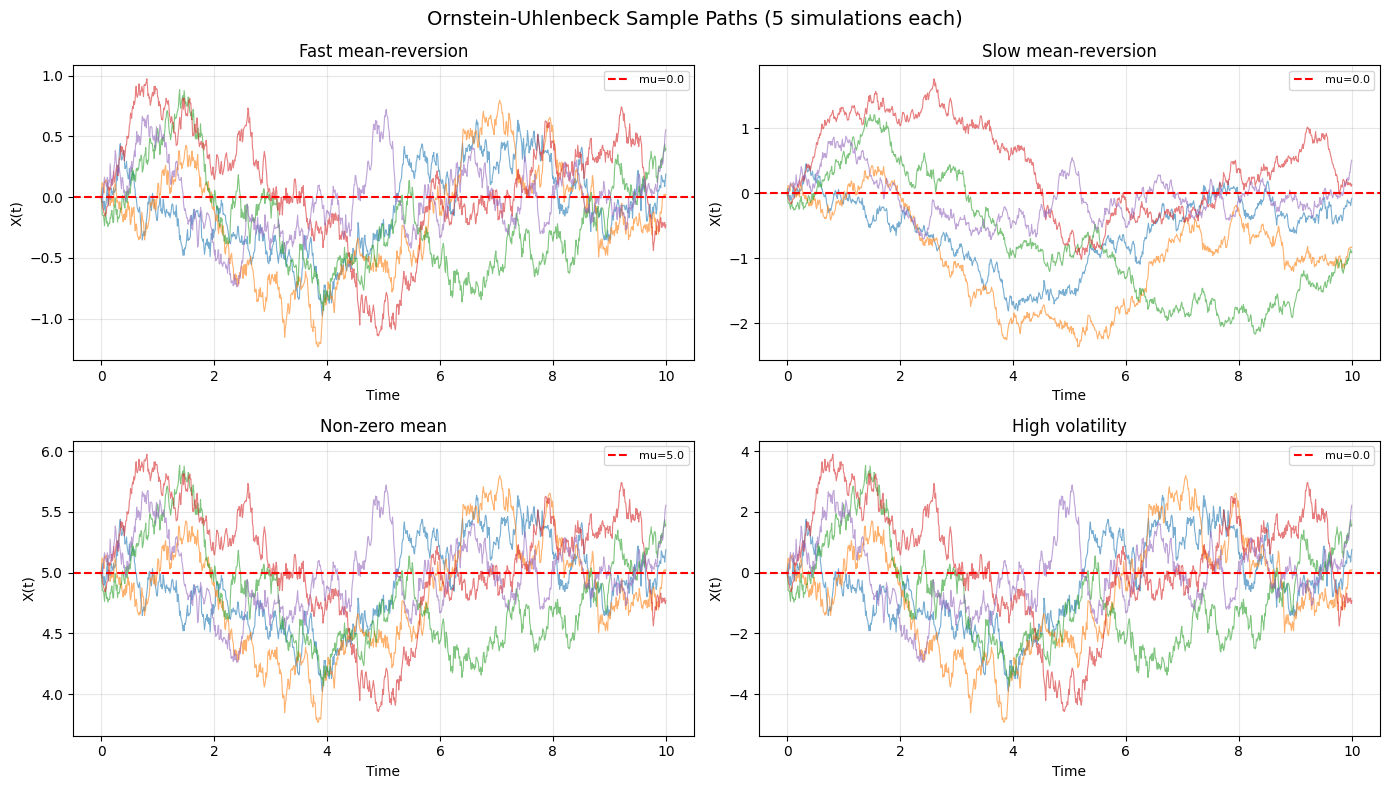

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for idx, p in enumerate(params):
    ax = axes[idx]
    # Plot multiple simulations overlaid
    for seed in range(5):
        path = pymlfinance.backtesting.simulate_ou(
            theta=p["theta"], mu=p["mu"], sigma=p["sigma"],
            x0=p["mu"], dt=0.01, n_steps=1000, seed=seed
        )
        t = np.linspace(0, 10, len(path))
        ax.plot(t, path, alpha=0.6, linewidth=0.8)
    ax.axhline(p["mu"], color="red", linestyle="--", linewidth=1.5, label=f"mu={p['mu']}")
    ax.set_title(p["label"])
    ax.set_xlabel("Time")
    ax.set_ylabel("X(t)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Ornstein-Uhlenbeck Sample Paths (5 simulations each)", fontsize=14)
plt.tight_layout()
plt.show()

## Parameter Estimation (Recovery Test)

Given a long simulated path, we estimate the OU parameters and compare
them to the true values. This validates that the estimator works
correctly.

In [4]:
true_theta, true_mu, true_sigma = 2.0, 1.0, 0.3
n_steps = 5000
dt = 0.01

path = pymlfinance.backtesting.simulate_ou(
    theta=true_theta, mu=true_mu, sigma=true_sigma,
    x0=true_mu, dt=dt, n_steps=n_steps, seed=42
)

est_theta, est_mu, est_sigma = pymlfinance.backtesting.estimate_ou_params(path, dt)
print(f"True:      theta={true_theta:.4f}, mu={true_mu:.4f}, sigma={true_sigma:.4f}")
print(f"Estimated: theta={est_theta:.4f}, mu={est_mu:.4f}, sigma={est_sigma:.4f}")
print(f"Error:     theta={abs(est_theta-true_theta)/true_theta:.1%}, "
      f"mu={abs(est_mu-true_mu)/max(abs(true_mu), 1e-10):.1%}, "
      f"sigma={abs(est_sigma-true_sigma)/true_sigma:.1%}")

True:      theta=2.0000, mu=1.0000, sigma=0.3000
Estimated: theta=2.3984, mu=1.0273, sigma=0.3004
Error:     theta=19.9%, mu=2.7%, sigma=0.1%


## Estimation Variance (10 Runs)

Running the simulation with different random seeds gives a sense of
the estimator's variance. The scatter plot below shows individual
estimates versus the true values.

In [5]:
thetas, mus, sigmas = [], [], []
for seed in range(10):
    path = pymlfinance.backtesting.simulate_ou(
        theta=true_theta, mu=true_mu, sigma=true_sigma,
        x0=true_mu, dt=dt, n_steps=n_steps, seed=seed
    )
    t, m, s = pymlfinance.backtesting.estimate_ou_params(path, dt)
    thetas.append(t)
    mus.append(m)
    sigmas.append(s)

print(f"theta: {np.mean(thetas):.4f} +/- {np.std(thetas):.4f} (true: {true_theta})")
print(f"mu:    {np.mean(mus):.4f} +/- {np.std(mus):.4f} (true: {true_mu})")
print(f"sigma: {np.mean(sigmas):.4f} +/- {np.std(sigmas):.4f} (true: {true_sigma})")

theta: 2.0566 +/- 0.2921 (true: 2.0)
mu:    0.9956 +/- 0.0208 (true: 1.0)
sigma: 0.3017 +/- 0.0021 (true: 0.3)


### Visualisation: Parameter Estimation Scatter

Each point represents a parameter estimate from a different random seed.
The red dashed lines mark the true values.

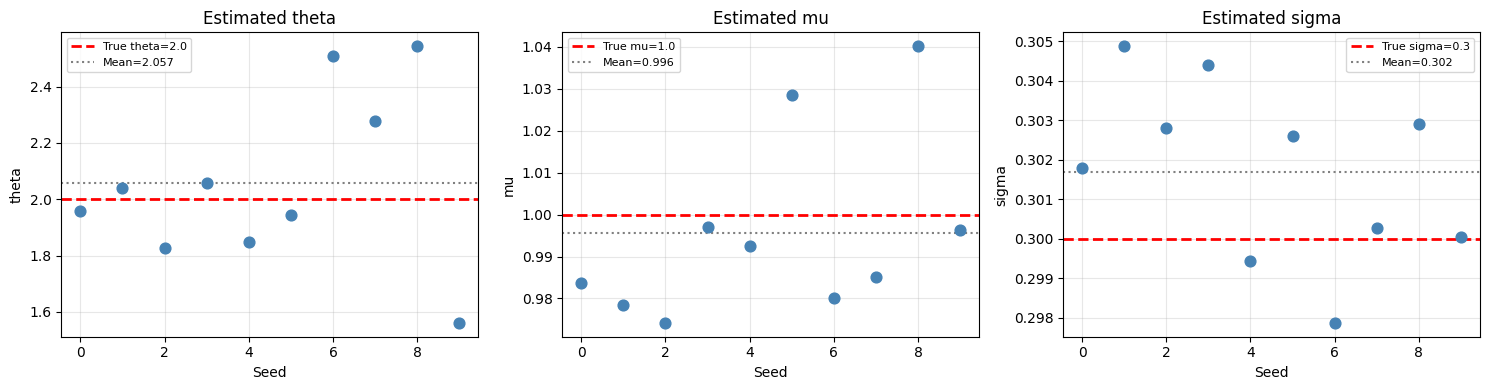

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, values, true_val, name in zip(
    axes,
    [thetas, mus, sigmas],
    [true_theta, true_mu, true_sigma],
    ["theta", "mu", "sigma"]
):
    ax.scatter(range(len(values)), values, s=60, zorder=5, color="steelblue")
    ax.axhline(true_val, color="red", linestyle="--", linewidth=2, label=f"True {name}={true_val}")
    ax.axhline(np.mean(values), color="gray", linestyle=":", linewidth=1.5, label=f"Mean={np.mean(values):.3f}")
    ax.set_xlabel("Seed")
    ax.set_ylabel(name)
    ax.set_title(f"Estimated {name}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Sample Size vs Estimation Quality

As the number of observed steps increases, the parameter estimates
converge to the true values. This demonstrates the consistency of the
estimator.

In [7]:
sample_sizes = [100, 500, 1000, 5000, 10000]
theta_errors = []

for n in sample_sizes:
    path = pymlfinance.backtesting.simulate_ou(
        theta=true_theta, mu=true_mu, sigma=true_sigma,
        x0=true_mu, dt=dt, n_steps=n, seed=42
    )
    t, m, s = pymlfinance.backtesting.estimate_ou_params(path, dt)
    theta_err = abs(t - true_theta) / true_theta
    theta_errors.append(theta_err)
    print(f"n={n:>5d}: theta_error={theta_err:.1%}, est_theta={t:.4f}")

n=  100: theta_error=411.5%, est_theta=10.2306
n=  500: theta_error=171.4%, est_theta=5.4274
n= 1000: theta_error=104.3%, est_theta=4.0861
n= 5000: theta_error=19.9%, est_theta=2.3984
n=10000: theta_error=1.0%, est_theta=2.0199


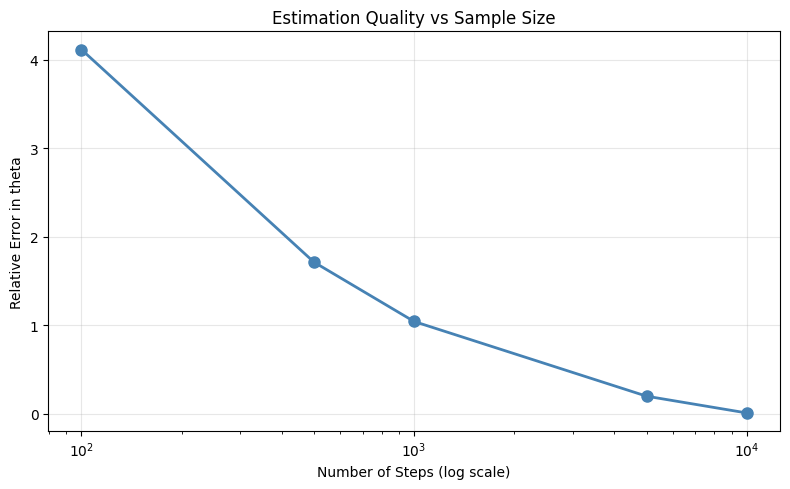

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sample_sizes, theta_errors, "o-", linewidth=2, markersize=8, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Number of Steps (log scale)")
ax.set_ylabel("Relative Error in theta")
ax.set_title("Estimation Quality vs Sample Size")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

1. Vary theta from 0.1 to 10.0 and observe how quickly paths revert.
2. Use estimated parameters to simulate new paths and compare distributions.
3. Test parameter recovery with different dt values (0.001, 0.01, 0.1).